In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.shape

(32581, 12)

In [5]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='str')

credit scoring model

objective- Predict an individual's creditworthiness using past financial data.


In [6]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(165)

In [63]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.shape

(32416, 12)

In [12]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [13]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

In [14]:
df["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [15]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64

Shows the class distribution percentage: roughly 78.13% low risk vs. 21.87% high risk, indicating a class imbalance.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

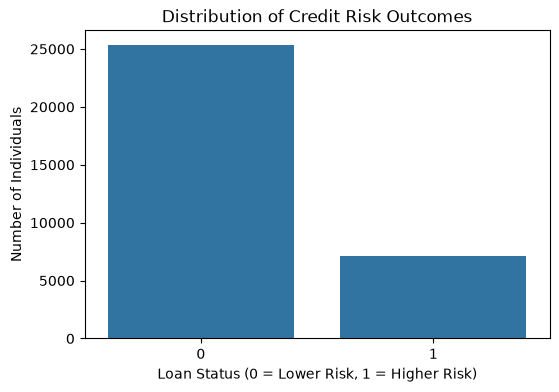

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x="loan_status", data=df)

plt.title("Distribution of Credit Risk Outcomes")
plt.xlabel("Loan Status (0 = Lower Risk, 1 = Higher Risk)")
plt.ylabel("Number of Individuals")

plt.show()

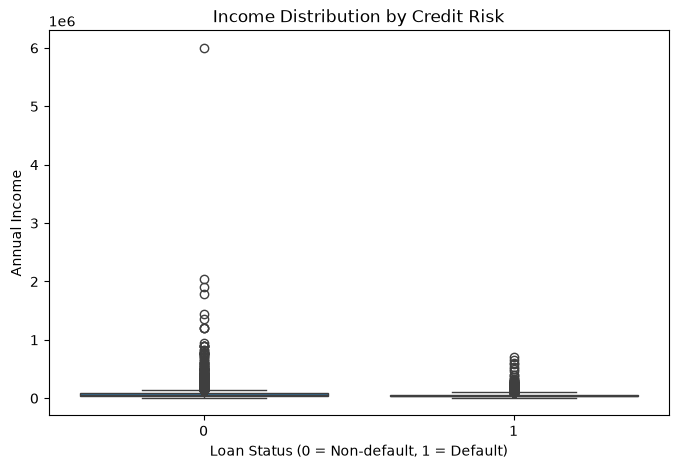

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="person_income",
    data=df
)

plt.title("Income Distribution by Credit Risk")
plt.xlabel("Loan Status (0 = Non-default, 1 = Default)")
plt.ylabel("Annual Income")

plt.show()

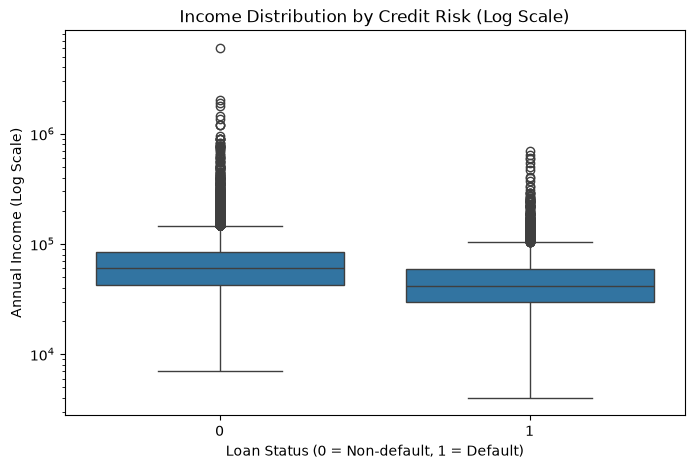

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="person_income",
    data=df
)

plt.yscale("log")

plt.title("Income Distribution by Credit Risk (Log Scale)")
plt.xlabel("Loan Status (0 = Non-default, 1 = Default)")
plt.ylabel("Annual Income (Log Scale)")

plt.show()

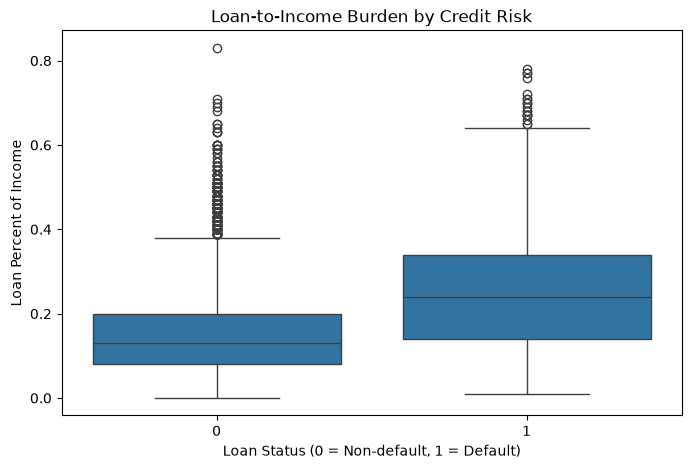

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_status",
    y="loan_percent_income",
    data=df
)

plt.title("Loan-to-Income Burden by Credit Risk")
plt.xlabel("Loan Status (0 = Non-default, 1 = Default)")
plt.ylabel("Loan Percent of Income")

plt.show()

In [21]:
df["income_loan_ratio"] = df["person_income"] / df["loan_amnt"]

In [22]:
df["estimated_interest_burden"] = (
    df["loan_amnt"] * df["loan_int_rate"] / 100
)

In [23]:
df["credit_history_ratio"] = (
    df["cb_person_cred_hist_length"] / df["person_age"]
)

In [24]:
df["employment_age_ratio"] = (
    df["person_emp_length"] / df["person_age"]
)

In [25]:
df[
    [
        "person_income",
        "loan_amnt",
        "loan_percent_income",
        "income_loan_ratio",
        "estimated_interest_burden",
        "credit_history_ratio",
        "employment_age_ratio"
    ]
].head()

,person_income,loan_amnt,loan_percent_income,income_loan_ratio,estimated_interest_burden,credit_history_ratio,employment_age_ratio
0,59000,35000,0.59,1.685714,5607.00,0.136364,5.590909
1,9600,1000,0.10,9.600000,111.40,0.095238,0.238095
2,9600,5500,0.57,1.745455,707.85,0.120000,0.040000
3,65500,35000,0.53,1.871429,5330.50,0.086957,0.173913
4,54400,35000,0.55,1.554286,4994.50,0.166667,0.333333


In [26]:
df["person_emp_length"].describe()

count    31529.00000
mean         4.79051
std          4.14549
min          0.00000
25%          2.00000
50%          4.00000
75%          7.00000
max        123.00000
Name: person_emp_length, dtype: float64

In [27]:
df["person_emp_length"].sort_values(ascending=False).head(20)

0        123.0
210      123.0
32355     41.0
32515     38.0
32428     34.0
31867     31.0
30914     31.0
31866     31.0
32263     31.0
32539     30.0
32562     30.0
32480     29.0
32142     28.0
31203     28.0
30844     28.0
31646     27.0
32503     27.0
30646     27.0
32379     27.0
30776     27.0
Name: person_emp_length, dtype: float64

In [28]:
df[["person_age", "person_emp_length"]].sort_values(
    "person_emp_length",
    ascending=False
).head(20)

,person_age,person_emp_length
0,22,123.0
210,21,123.0
32355,78,41.0
32515,53,38.0
32428,58,34.0
31867,46,31.0
30914,48,31.0
31866,47,31.0
32263,46,31.0
32539,61,30.0


In [29]:
df["person_emp_length"] = df["person_emp_length"].replace(
    123, df["person_emp_length"].median()
)

In [30]:
df["person_emp_length"].max()

np.float64(41.0)

In [31]:
df["employment_age_ratio"] = (
    df["person_emp_length"] / df["person_age"]
)

In [32]:
df[[
    "income_loan_ratio",
    "estimated_interest_burden",
    "credit_history_ratio",
    "employment_age_ratio"
]].describe()

,income_loan_ratio,estimated_interest_burden,credit_history_ratio,employment_age_ratio
count,32416.000000,29321.000000,32416.000000,31529.000000
mean,9.762852,1086.380148,0.194888,0.174004
std,14.902984,879.009841,0.093594,0.135268
min,1.204819,48.800000,0.013889,0.000000
25%,4.363636,475.615000,0.125000,0.064516
50%,6.750000,820.000000,0.173913,0.142857
75%,11.146885,1423.200000,0.261905,0.272727
max,1266.666667,7087.500000,0.588235,0.716981


In [33]:
df[["person_age", "person_emp_length", "employment_age_ratio"]].sort_values(
    "employment_age_ratio",
    ascending=False
).head(10)

,person_age,person_emp_length,employment_age_ratio
32515,53,38.0,0.716981
31867,46,31.0,0.673913
32263,46,31.0,0.673913
31866,47,31.0,0.659574
30914,48,31.0,0.645833
30844,44,28.0,0.636364
32142,44,28.0,0.636364
31203,44,28.0,0.636364
30646,43,27.0,0.627907
30776,43,27.0,0.627907


In [34]:
df["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [35]:
df["loan_status"].value_counts(normalize=True) * 100

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64

## ml model

In [36]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [37]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32416, 15)
y shape: (32416,)


In [38]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "income_loan_ratio",
    "estimated_interest_burden",
    "credit_history_ratio",
    "employment_age_ratio"
]

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (25932, 15)
Testing set: (6484, 15)

Training target distribution:
loan_status
0    0.781313
1    0.218687
Name: proportion, dtype: float64

Testing target distribution:
loan_status
0    0.781308
1    0.218692
Name: proportion, dtype: float64


Preprocessing Pipeline

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

logistic regression

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [43]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [44]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['person_age','person_income','person_home_ownership',..., 'estimated_interest_burden','credit_history_ratio','employment_age_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [45]:
y_pred = logistic_model.predict(X_test)

In [46]:
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [48]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8160086366440469
Precision: 0.5573686894441612
Recall   : 0.7708039492242595
F1-Score : 0.6469369635986978
ROC-AUC  : 0.869684063172888


In [49]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      5066
           1       0.56      0.77      0.65      1418

    accuracy                           0.82      6484
   macro avg       0.74      0.80      0.76      6484
weighted avg       0.85      0.82      0.83      6484



The Logistic Regression model achieved an accuracy of 81.60% and a ROC-AUC score of 86.97%. It obtained a recall of 77.08% for the higher-risk/default class, indicating that the model was able to identify a substantial proportion of observed default cases. The precision was 55.74%, showing that some borrowers predicted as higher-risk were actually non-default borrowers. Overall, the model provides a useful baseline for predicting credit risk and assessing creditworthiness."

decision tree

In [50]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced",
            max_depth=8,
            random_state=42
        ))
    ]
)

In [51]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['person_age','person_income','person_home_ownership',..., 'estimated_interest_burden','credit_history_ratio','employment_age_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [52]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [53]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1-Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9181061073411474
Precision: 0.8893766461808604
Recall   : 0.7143864598025388
F1-Score : 0.7923347673054361
ROC-AUC  : 0.9022299163036633

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5066
           1       0.89      0.71      0.79      1418

    accuracy                           0.92      6484
   macro avg       0.91      0.84      0.87      6484
weighted avg       0.92      0.92      0.91      6484



Decision Tree Performance:

The Decision Tree model achieved an accuracy of 91.81% and a ROC-AUC score of 90.22%. It achieved a precision of 88.94% and an F1-score of 79.23% for the higher-risk/default class. Its recall was 71.44%, which was lower than the Logistic Regression model's recall of 77.08%. This indicates that the Decision Tree provides higher precision while Logistic Regression identifies a larger proportion of the observed default cases.

Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [55]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['person_age','person_income','person_home_ownership',..., 'estimated_interest_burden','credit_history_ratio','employment_age_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (def

In [56]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [57]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9302899444787168
Precision: 0.9207317073170732
Recall   : 0.7454160789844851
F1-Score : 0.8238503507404521
ROC-AUC  : 0.9316251154715443

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      5066
           1       0.92      0.75      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.93      0.86      0.89      6484
weighted avg       0.93      0.93      0.93      6484



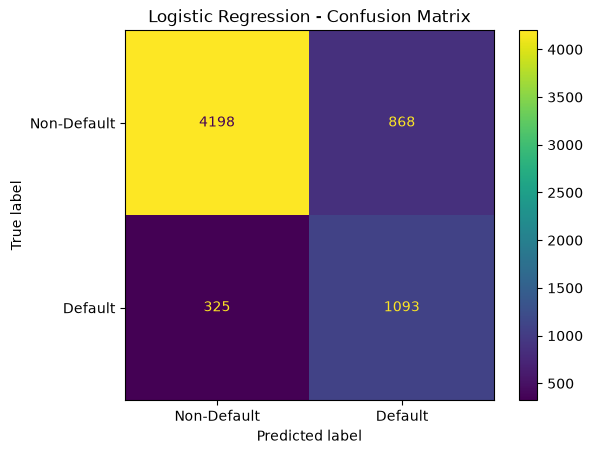

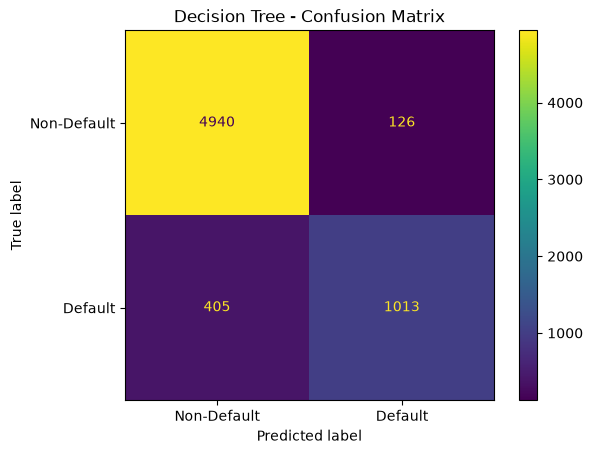

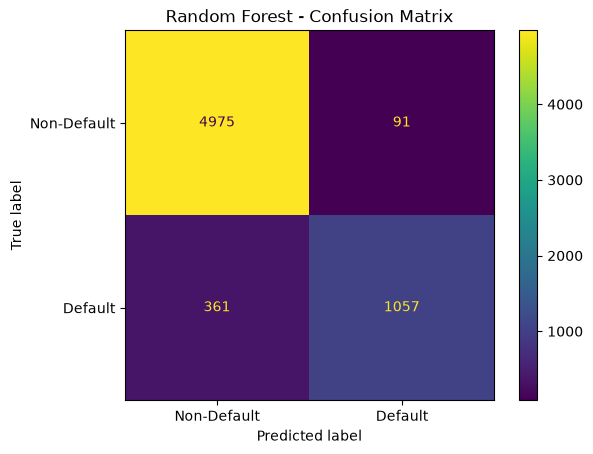

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot Logistic Regression
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Plot Decision Tree
ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Plot Random Forest
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Non-Default", "Default"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

Confusion Matrix Analysis:

The confusion matrices show the classification performance of all three models. Logistic Regression identified the largest number of actual default cases, with 1093 true positives, but also produced 868 false positives. The Decision Tree reduced false positives to 126, but produced 405 false negatives. Random Forest produced the fewest false positives, with 91 cases, while correctly identifying 1057 default cases. These results demonstrate the different precision–recall trade-offs among the three models.

ROC Curve

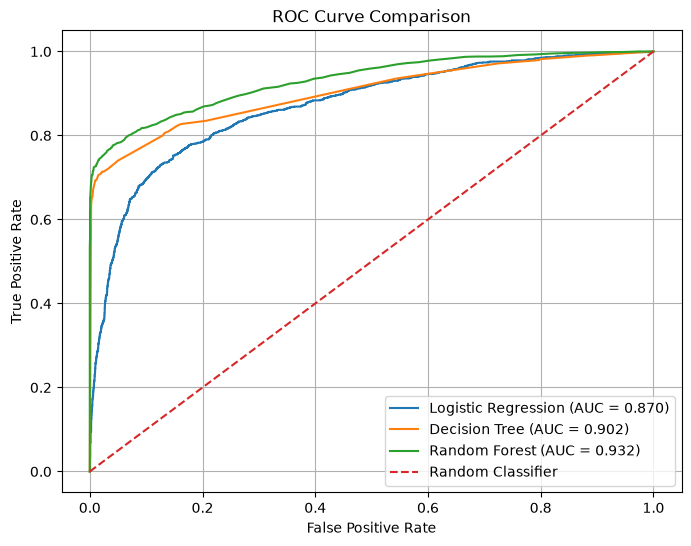

In [59]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr, tpr_lr,
    label=f"Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})"
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {auc(fpr_rf, tpr_rf):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

ROC Curve Analysis:

The ROC curves were plotted to compare the ability of the three classification models to distinguish between non-default and default cases across different classification thresholds. Logistic Regression achieved an AUC of 0.870, Decision Tree achieved an AUC of 0.902, and Random Forest achieved an AUC of 0.932. The results show that all three models have useful discriminatory ability, with Random Forest obtaining the highest ROC-AUC of 0.932 among the tested models.

In [60]:
# Get the trained Random Forest classifier
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = rf_classifier.feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
print(feature_importance_df.head(15))

                                Feature  Importance
7                num__income_loan_ratio    0.138040
1                    num__person_income    0.118359
4                    num__loan_int_rate    0.107215
5              num__loan_percent_income    0.103263
8        num__estimated_interest_burden    0.054018
24                    cat__loan_grade_D    0.048729
3                        num__loan_amnt    0.047786
10            num__employment_age_ratio    0.040033
14      cat__person_home_ownership_RENT    0.037886
9             num__credit_history_ratio    0.035161
2                num__person_emp_length    0.030799
0                       num__person_age    0.030124
6       num__cb_person_cred_hist_length    0.022058
21                    cat__loan_grade_A    0.022022
11  cat__person_home_ownership_MORTGAGE    0.019559


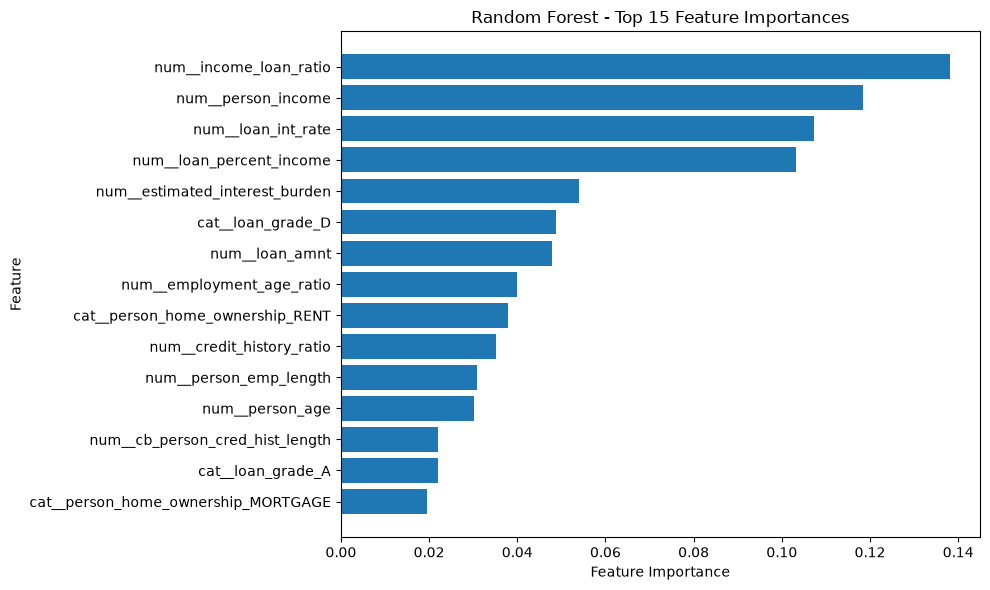

In [61]:
plt.figure(figsize=(10, 6))

top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Top 15 Feature Importances")
plt.tight_layout()
plt.show()

Feature Importance Analysis:

The Random Forest feature-importance analysis shows that income-to-loan ratio was the most influential feature, followed by person income, loan interest rate, and loan percent income. Other important features included estimated interest burden, loan grade, loan amount, employment-age ratio, and home ownership. The engineered features, particularly income-to-loan ratio, estimated interest burden, employment-age ratio, and credit-history ratio, contributed to the model's predictions. Overall, the feature-importance results suggest that financial capacity, loan burden, interest rate, employment characteristics, and credit-history-related variables provide useful information for distinguishing between the observed credit-risk classes. Feature importance represents predictive contribution within this model and should not be interpreted as a causal relationship.

In [62]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(model_results)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.816009   0.557369  0.770804  0.646937  0.869684
1        Decision Tree  0.918106   0.889377  0.714386  0.792335  0.902230
2        Random Forest  0.930290   0.920732  0.745416  0.823850  0.931625


Conclusion

The credit scoring model was developed to predict an individual's creditworthiness using financial and credit-history-related features. Three classification algorithms—Logistic Regression, Decision Tree, and Random Forest—were evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The Random Forest model achieved 93.03% accuracy, 92.07% precision, 82.39% F1-score, and 93.16% ROC-AUC, while Logistic Regression achieved the highest recall of 77.08% for the higher-risk/default class. The results demonstrate that the selected financial and credit-history features provide useful predictive information for distinguishing between lower-risk and higher-risk borrowers.